# <span style="color: purple;">Lesson 2 - Your First Machine Learning Model</span>

**Developers:** Brian &nbsp;|&nbsp; **Reviewers:** Alina, Mungo

---

## <span style="color: purple;">🎯 Learning Objectives</span>

By the end of this lesson, you will have:

- Loaded and explored a real dataset of 150 flowers
- Trained your first AI model to identify flower species from measurements
- Seen the difference between an untrained and a trained model side by side
- Measured how accurate a model is and understood what that means

<div class="alert alert-info">

**How it works:** Click the ▶ button on the top left of each code cell, top to bottom. Read the explanation after you see the output. That's it!

</div>

In [10]:
# ─────────────────────────────────────────────────────────────
# Setup cell — run this first, then you can ignore it
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from tqdm.notebook import tqdm

print("✓ Ready to go!")

✓ Ready to go!


---

## <span style="color: purple;">🧩 What is Classification?</span>

Your phone's spam filter, Netflix recommendations, and face unlock all use the same idea: a computer that learns to sort things into groups.

<div class="alert alert-success">

**Classification** - The task of sorting data into groups (e.g. is this animal a cat or a dog?)

</div>

Instead of being told the rules, the computer learns from examples. Show it enough data and it figures out the pattern itself.

Here are some everyday examples:

| Thing to sort | What gets measured | What it predicts |
|-------|--------------------|-----------------|
| 📧 Email | Words, sender, links | **Spam** or **Inbox** |
| 📸 Medical scan | Shapes, brightness | **Healthy** or **Tumour** |
| 🎮 Gamer | Time played, wins | **Pro** or **Noob** |
| 🖼️ Animal photo | Colour, ear shape, size | **Cat**, **Dog**, or **Horse** |

---

## <span style="color: purple;">Step 1 - Look at the data</span>

We're going to teach a computer to identify three species of iris flower just from their measurements.

The dataset has **150 flowers**. Each one has 4 measurements, known as **features**, and a **label** saying which species it is.

<div class="alert alert-success">

**Features** - The measurements used to make a prediction. Here, the features are the four physical measurements of each flower (petal length, petal width, sepal length, sepal width).

</div>

<div class="alert alert-success">

**Label** - The correct answer for each flower in the dataset (e.g. "setosa"). The model learns by studying these labels during training.

</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Petal-sepal.jpg/500px-Petal-sepal.jpg" alt="Petal and Sepal Diagram" width="250" style="margin-top:10px; margin-bottom:15px; border-radius: 8px;"/>

| Measurement | Example value |
|-------------|--------------|
| Sepal length (cm) | 5.1 |
| Sepal width (cm) | 3.5 |
| Petal length (cm) | 1.4 |
| Petal width (cm) | 0.2 |

The 3 species we're trying to predict:

|*Species 1*|*Species 2*|*Species 3*|
|:---:|:---:|:---:|
| **Setosa** | **Versicolor** | **Virginica** |
| <img src="https://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg" alt="Iris Setosa" width="200"/> | <img src="https://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg" alt="Iris Versicolor" width="200"/> | <img src="https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg" alt="Iris Virginica" width="200"/> |

<div class="alert alert-info">

**Run the next two cells** to load the data and plot it.

</div>

In [11]:
# Load the dataset
iris = load_iris()

# Put it in a DataFrame so it's easy to read
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

display(df.head())
print("✓ Data loaded")

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


✓ Data loaded


The table above shows the first 5 flowers in the dataset. Each row is one flower, with its four measurements and the species label. There are 150 flowers in total.

Now let's plot the data to see if the three species look different from each other.

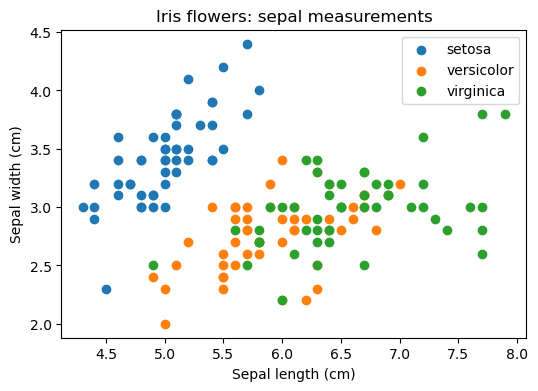

✓ Plot shown


In [12]:
# Plot sepal length vs sepal width, coloured by species
plt.figure(figsize=(6, 4))
for species in iris.target_names:
    subset = df[df['species'] == species]
    plt.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], label=species)
plt.title('Iris flowers: sepal measurements')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.legend()
plt.show()
print("✓ Plot shown")

<div class="alert alert-info">

### 👀 What are we looking at?

- **The table** shows the first 5 flowers. Each row is one flower, with its measurements and species label.

- **The plot** shows all 150 flowers. Each dot is one flower, coloured by species. Notice how the setosa flowers (blue) are clearly separated from the others. The model's job is to learn these boundaries automatically.

</div>

---

## <span style="color: purple;">Step 2 - Train the model</span>

First we split the data - 120 flowers to learn from, 30 held back for testing.

Then we run two models: an **untrained** one that not seen any data, and a properly **trained** one. In Step 3, we test them both.

In [13]:
X = iris.data
y = iris.target

# Keep 80% to train on, hold back 20% to test on
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Flowers for training: {len(X_train)}")
print(f"Flowers for testing:  {len(X_test)}")

Flowers for training: 120
Flowers for testing:  30


The model will learn from the training flowers and then be tested on the 30 it has never seen.

Next, we create an **untrained** model - one that hasn't learned anything yet - so we can compare it to a trained one later.

In [14]:
untrained = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=1, random_state=42)
untrained.fit(X_train, y_train)
    
print("✓ Untrained model created")

✓ Untrained model created


<div class="alert alert-info">

That's the **untrained** model - it's had no chance to learn, so its predictions will likely be all over the place. Now let's train the model.

</div>

<div class="alert alert-success">

**Training** - The process of a model learning the patterns in the data it is given.

</div>

In [15]:
# Create and train the model
chunk = 50
model = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=chunk, warm_start=True, random_state=42)

for _ in tqdm(range(1000 // chunk), desc="Training"):
    model.fit(X_train, y_train)
    model.max_iter += chunk
    time.sleep(0.5)  # Simulate time taken to train

print("Model trained!")

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Model trained!


<div class="alert alert-info">

### 🎉 The model is trained - now let's test it!

Keep going to see how it does on the 30 flowers it's never seen before.

</div>

---

## <span style="color: purple;">Step 3 - Test both models</span>

Now we give the trained and untrained models the same 30 flowers they've never seen and ask them to identify the species.

<div class="alert alert-success">

**Prediction** - The model's guess for something it hasn't seen before, based on what it learned during training.

</div>

It's like giving two students the same exam - one who revised properly, and one who barely glanced at the notes.

In [16]:
untrained_pred = untrained.predict(X_test)
y_pred = model.predict(X_test)

print(f"Untrained model accuracy:   {accuracy_score(y_test, untrained_pred) * 100:.1f}%")
print(f"Trained model accuracy:   {accuracy_score(y_test, y_pred) * 100:.1f}%")

print("\nFirst 5 predictions vs. actual:")
comparison = pd.DataFrame({
    'Untrained guess': iris.target_names[untrained_pred[:5]],
    'Trained guess':  iris.target_names[y_pred[:5]],
    'Actual':         iris.target_names[y_test[:5]]
})
display(comparison)

Untrained model accuracy:   33.3%
Trained model accuracy:   100.0%

First 5 predictions vs. actual:


,Untrained guess,Trained guess,Actual
0,setosa,versicolor,versicolor
1,setosa,setosa,setosa
2,setosa,virginica,virginica
3,setosa,versicolor,versicolor
4,setosa,versicolor,versicolor


<div class="alert alert-success">

**Accuracy** - The percentage of predictions that were correct. If the model correctly identifies 30 out of 30 flowers, its accuracy is 100%.

</div>

<div class="alert alert-info">

### ⁉️ Wait - 100%?

These three flower species happen to be very easy to tell apart from their measurements, so 100% is possible here. In the real world, you'll almost never see this. If you do, it's usually a sign something went wrong (like the model accidentally got to see the test answers during training).

</div>

---

## <span style="color: purple;">🧠 What did we just do?</span>

We started with a dataset of 150 real flowers, each measured in four ways. We split them into a training set (120 flowers) and a test set (30 flowers the model never saw).

We trained two models: one that barely learned anything, and one that went through the data 1000 times. When we tested them both on the same 30 flowers, the difference was clear - more training led to much better predictions.

That's the core idea behind machine learning: show a model enough labelled examples, and it learns to make good predictions on its own.

---

### Key words

| Word | What it means |
|------|--------------|
| **Classification** | Sorting things into groups (e.g. which species?) |
| **Features** | The measurements we use to make the prediction |
| **Label** | The correct answer (the species name) |
| **Training** | Showing the model examples so it can learn the pattern |
| **Prediction** | The model's guess on a flower it hasn't seen |
| **Accuracy** | The percentage of guesses that were correct |

The key rule: **always test on data the model hasn't trained on.** Testing on the same data it learned from would be like marking your own homework.

---

## <span style="color: purple;">🔧 Your turn!</span>

The trained model went through the data **1000 times**. More time to learn usually means better predictions - but is more always better?

**Change `training_steps` below to control how long the model can learn for, then re-run. What happens to the accuracy?**

In [17]:
# ▼▼▼▼▼▼▼▼▼▼▼▼▼▼  CHANGE THIS  ▼▼▼▼▼▼▼▼▼▼▼▼▼▼
training_steps = 50   # ← try 5, 50, or 5000
# ▲▲▲▲▲▲▲▲▲▲▲▲▲▲  CHANGE THIS  ▲▲▲▲▲▲▲▲▲▲▲▲▲▲

model2 = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=training_steps, random_state=42)
model2.fit(X_train, y_train)

print(f"Learning for {training_steps} steps → Accuracy: {accuracy_score(y_test, model2.predict(X_test)) * 100:.1f}%")

Learning for 50 steps → Accuracy: 96.7%


---

## <span style="color: purple;">🧪 Quick Quiz</span>

Test yourself on what you just learned. Run the code cell, select your answer for each question, then click **Check answers**.


In [18]:
from quiz import run_b02_quiz
run_b02_quiz()